# Atlante delle mappe — **dati corretti v3**

Riproduce **esattamente** l'atlante `dati/atlante_mappe_progetto.ipynb` (stesse
mappe, stessi gradienti, stesse legende), cambiando solo la sorgente dei dati:

    gap_score        ->  gap_score_v3     (GAP ricalcolato)
    domanda_corretta ->  domanda_v3       (EV dopo correzione flotte + composizione del parco)

L'atlante originale **non e' stato modificato**. Le immagini qui hanno il
prefisso `atlantev3_` per non sovrascrivere quelle originali (`atlante_`, in
`dati/`). La correzione v3 deflaziona le province-hub in base alla COMPOSIZIONE del
parco (non in proporzione): vedi `04_correzione_v3_composizione.py`.

> **Nota sulla soglia.** Questo atlante usa `SOGLIA = 0,4` per definire un
> "deserto", com'era nell'originale. Gli altri notebook piu' recenti usano
> **0,429**, la soglia individuata col metodo del gomito. Il valore e' stato
> lasciato invariato per fedelta' all'originale: per allinearlo basta cambiare
> `SOGLIA` nella cella di configurazione e rieseguire.

Le colonnine di ricarica e i contorni provinciali sono gli stessi: la
correzione riguarda solo la domanda di ricarica, non l'offerta.

In [1]:
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, LogNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from pathlib import Path

QUI = Path(".")        # cartella CORREZIONE_v2_MOTORIZZAZIONE
DATI = Path("..")      # cartella dati/ (Path(".").parent non risale: serve "..")
PARQUET = QUI / "sezioni_gap_v3.parquet"          # <-- dati corretti v3
COLONNINE = DATI / "pun_colonnine_pulito.csv"
PROV_GEOM = DATI / "province_geom.parquet"
CRS = "EPSG:32632"
SOGLIA = 0.4          # invariata rispetto all'atlante originale (vedi nota in testa)

print("Carico sezioni...")
# il file v3 e' gia' un GeoParquet: la geometria non va ricostruita da WKB
gdf = gpd.read_parquet(PARQUET, columns=[
    "SEZ2011","PROVINCIA","popolazione_eta_guida_stimata",
    "gap_score_v3","domanda_v3","geometry"]).rename(
    columns={"popolazione_eta_guida_stimata":"popg"})
gdf["PROCOM"] = (gdf.SEZ2011 // 10_000_000).astype("int64")
gdf["CODPRO"] = (gdf.PROCOM // 1000).astype("int64")
gdf["px"] = gdf.geometry.centroid.x
gdf["py"] = gdf.geometry.centroid.y
e = gdf[gdf.gap_score_v3.notna()]

if PROV_GEOM.exists():
    prov_geo = gpd.read_parquet(PROV_GEOM)
else:                                  # ricostruzione dei contorni provincia
    print("Creo province_geom (dissolve ~1 min)...")
    tmp = gdf[["CODPRO","geometry"]].copy()
    prov_geo = tmp.dissolve(by="CODPRO"); prov_geo["geometry"] = prov_geo.geometry.simplify(250)
    prov_geo.to_parquet(PROV_GEOM)

col = pd.read_csv(COLONNINE)
col_g = gpd.GeoDataFrame(col, geometry=gpd.points_from_xy(col.longitude, col.latitude),
                         crs="EPSG:4326").to_crs(CRS)
print(f"Sezioni {len(gdf):,} | eleggibili {len(e):,} | province {len(prov_geo)} | colonnine {len(col_g):,}")

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Carico sezioni...


Sezioni 402,678 | eleggibili 346,507 | province 110 | colonnine 72,648


In [2]:
agg = e.groupby("CODPRO").agg(
    ev=("domanda_v3","sum"), pop_tot=("popg","sum"),
    gap_medio=("gap_score_v3", lambda s: np.average(s, weights=e.loc[s.index,"popg"])),
)
agg["ev_per_1000"] = agg.ev/agg.pop_tot*1000
agg["quota_deserto"] = e["popg"].where(e.gap_score_v3>SOGLIA,0.0).groupby(e.CODPRO).sum()/agg.pop_tot
sj = gpd.sjoin(col_g[["geometry"]], prov_geo.reset_index()[["CODPRO","geometry"]], predicate="within")
agg["colonnine"] = sj.groupby("CODPRO").size()
agg["colonnine_per_10000"] = agg.colonnine/agg.pop_tot*10000
P = prov_geo.join(agg)

def m_hexbin(x, y, C, cmap, titolo, fname, reduce=np.mean, gridsize=75,
             norm=None, vmin=None, vmax=None, label=""):
    fig, ax = plt.subplots(figsize=(9, 11))
    hb = ax.hexbin(x, y, C=C, reduce_C_function=reduce, gridsize=gridsize, cmap=cmap,
                   mincnt=1, norm=norm, vmin=vmin, vmax=vmax)
    ax.set_axis_off(); ax.set_aspect("equal"); ax.set_title(titolo, fontsize=13)
    fig.colorbar(hb, ax=ax, shrink=0.55, pad=0.01, label=label)
    plt.tight_layout(); plt.savefig(fname, dpi=160, bbox_inches="tight"); plt.show()

def m_choro(gdfp, col_name, cmap, titolo, fname, norm=None, vmin=None, vmax=None,
            label="", edge="white", extend="neither"):
    fig, ax = plt.subplots(figsize=(9, 11))
    gdfp.plot(column=col_name, cmap=cmap, ax=ax, edgecolor=edge, linewidth=0.25,
              norm=norm, vmin=vmin, vmax=vmax, legend=True,
              legend_kwds={"shrink":0.55, "pad":0.01, "label":label, "extend":extend},
              missing_kwds={"color":"#dddddd"})
    ax.set_axis_off(); ax.set_title(titolo, fontsize=13)
    plt.tight_layout(); plt.savefig(fname, dpi=160, bbox_inches="tight"); plt.show()
print("helper e aggregati pronti")


helper e aggregati pronti


# Parte 1 — Colonnine di ricarica

## 1a. Mappa a punti — rosso su bianco

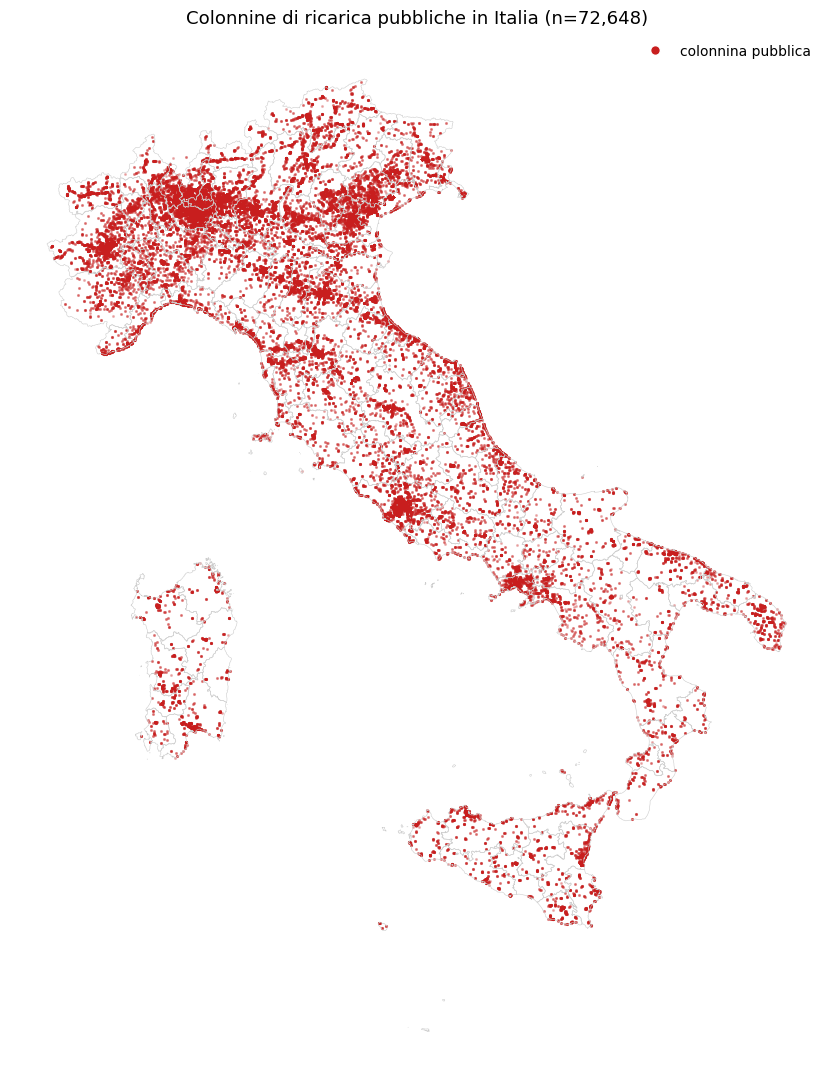

In [3]:
fig, ax = plt.subplots(figsize=(9, 11))
prov_geo.boundary.plot(ax=ax, color="#cccccc", linewidth=0.4)
col_g.plot(ax=ax, markersize=1.5, color="#c81e1e", alpha=0.25)
ax.set_axis_off(); ax.set_title(f"Colonnine di ricarica pubbliche in Italia (n={len(col_g):,})", fontsize=13)
ax.legend([Line2D([0],[0], marker="o", color="w", markerfacecolor="#c81e1e", markersize=7)],
          ["colonnina pubblica"], loc="upper right", frameon=False)
plt.tight_layout(); plt.savefig("atlantev3_1a_punti_rosso.png", dpi=160, bbox_inches="tight"); plt.show()


## 1a-bis. Mappa a punti — colorati per densità locale (con colorbar)
Ogni colonnina è colorata in base a quante altre ce ne sono attorno: i cluster
urbani risaltano.

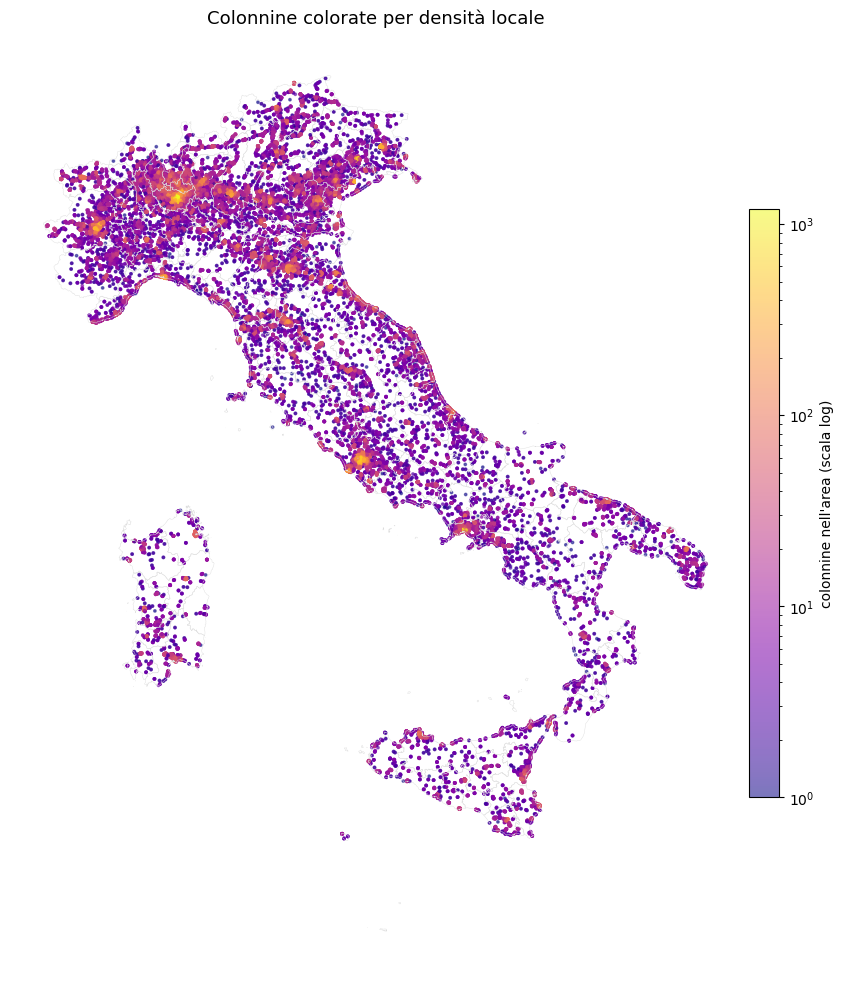

In [4]:
x, y = col_g.geometry.x.values, col_g.geometry.y.values
H, xe, ye = np.histogram2d(x, y, bins=220)
ix = np.clip(np.digitize(x, xe)-1, 0, H.shape[0]-1)
iy = np.clip(np.digitize(y, ye)-1, 0, H.shape[1]-1)
dens = H[ix, iy]
fig, ax = plt.subplots(figsize=(9, 11))
prov_geo.boundary.plot(ax=ax, color="#dddddd", linewidth=0.3)
sc = ax.scatter(x, y, c=dens, cmap="plasma", s=3, alpha=0.55, norm=LogNorm(vmin=1, vmax=dens.max()))
ax.set_axis_off(); ax.set_aspect("equal")
ax.set_title("Colonnine colorate per densità locale", fontsize=13)
fig.colorbar(sc, ax=ax, shrink=0.55, pad=0.01, label="colonnine nell'area (scala log)")
plt.tight_layout(); plt.savefig("atlantev3_1a_punti_colorati.png", dpi=160, bbox_inches="tight"); plt.show()


## 1b. Densità a esagoni — test di gradienti (colorbar per ognuno)

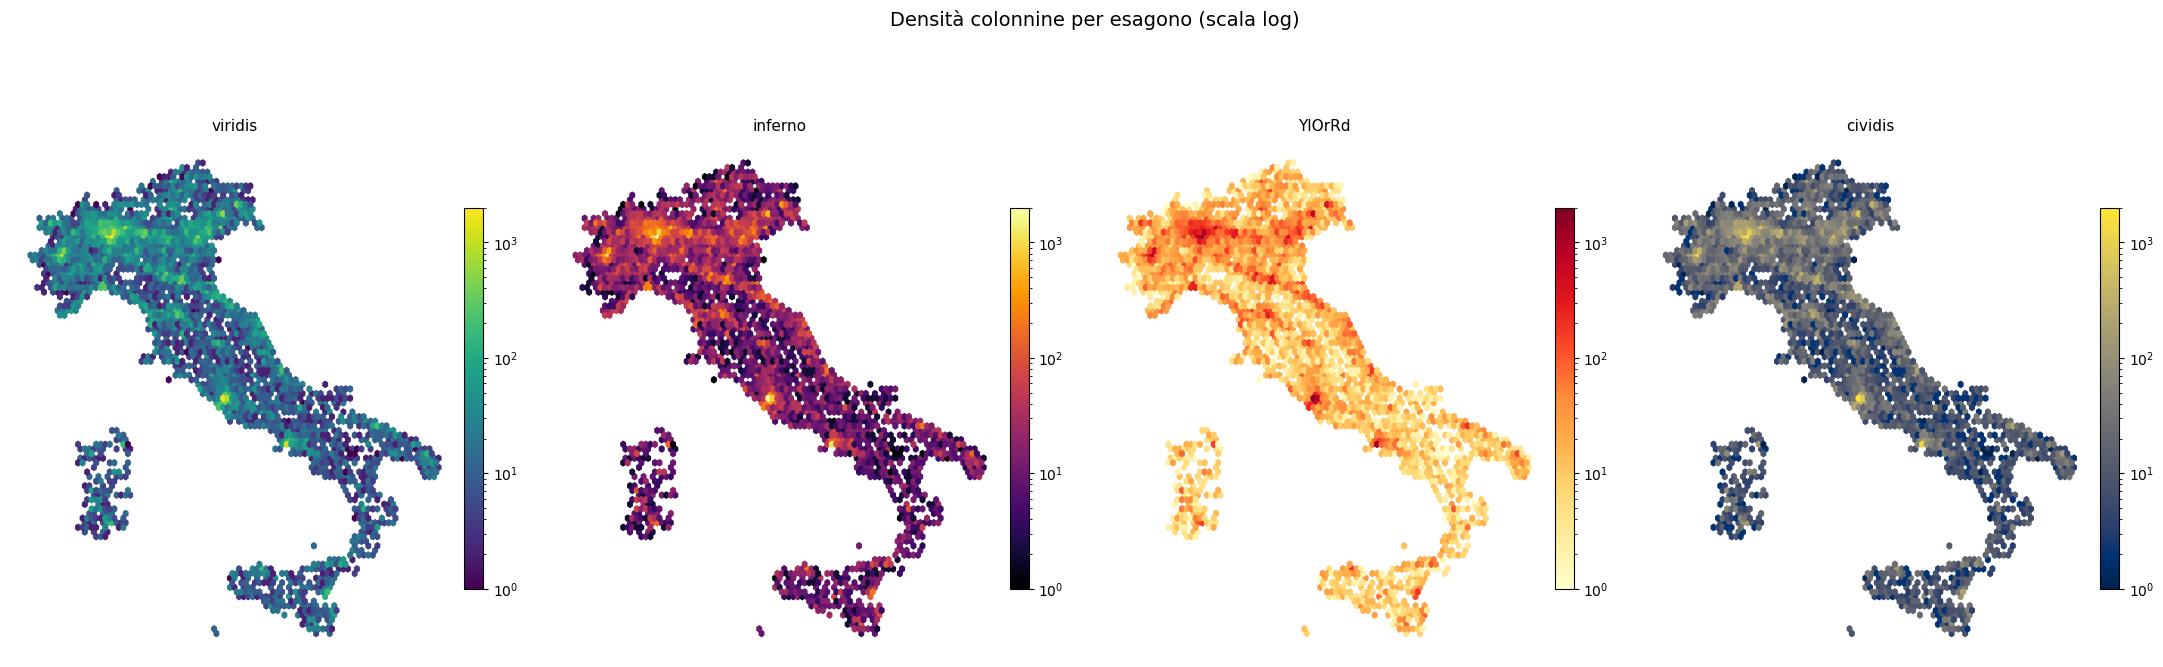

In [5]:
xs, ys = col_g.geometry.x.values, col_g.geometry.y.values
uni = np.ones(len(xs))
fig, axes = plt.subplots(1, 4, figsize=(22, 7))
for ax, cm in zip(axes, ["viridis","inferno","YlOrRd","cividis"]):
    hb = ax.hexbin(xs, ys, C=uni, reduce_C_function=np.sum, gridsize=90, cmap=cm,
                   mincnt=1, norm=LogNorm(vmin=1, vmax=2000))
    ax.set_axis_off(); ax.set_aspect("equal"); ax.set_title(cm, fontsize=11)
    fig.colorbar(hb, ax=ax, shrink=0.6, pad=0.01)
fig.suptitle("Densità colonnine per esagono (scala log)", fontsize=14, y=1.03)
plt.tight_layout(); plt.savefig("atlantev3_1b_densita.png", dpi=150, bbox_inches="tight"); plt.show()


## 1c. Colonnine per provincia — gradiente di blu (chiaro=poche, scuro=molte)
Due letture: numero assoluto di colonnine e colonnine ogni 10.000 residenti.

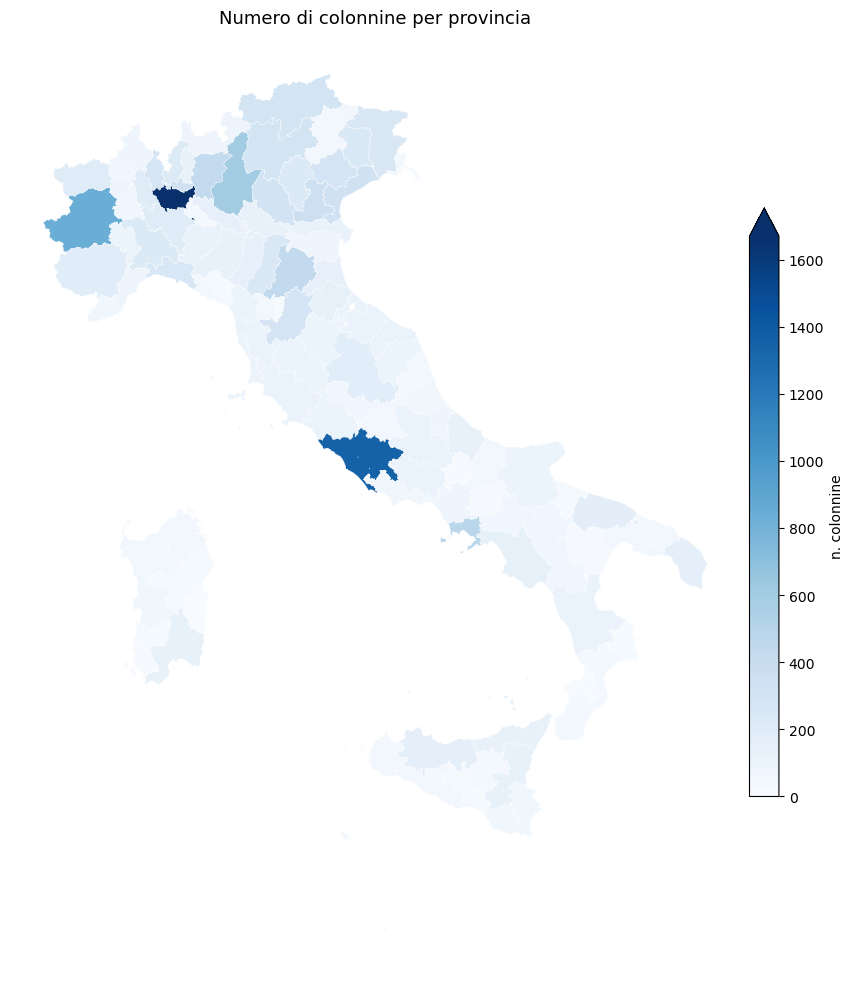

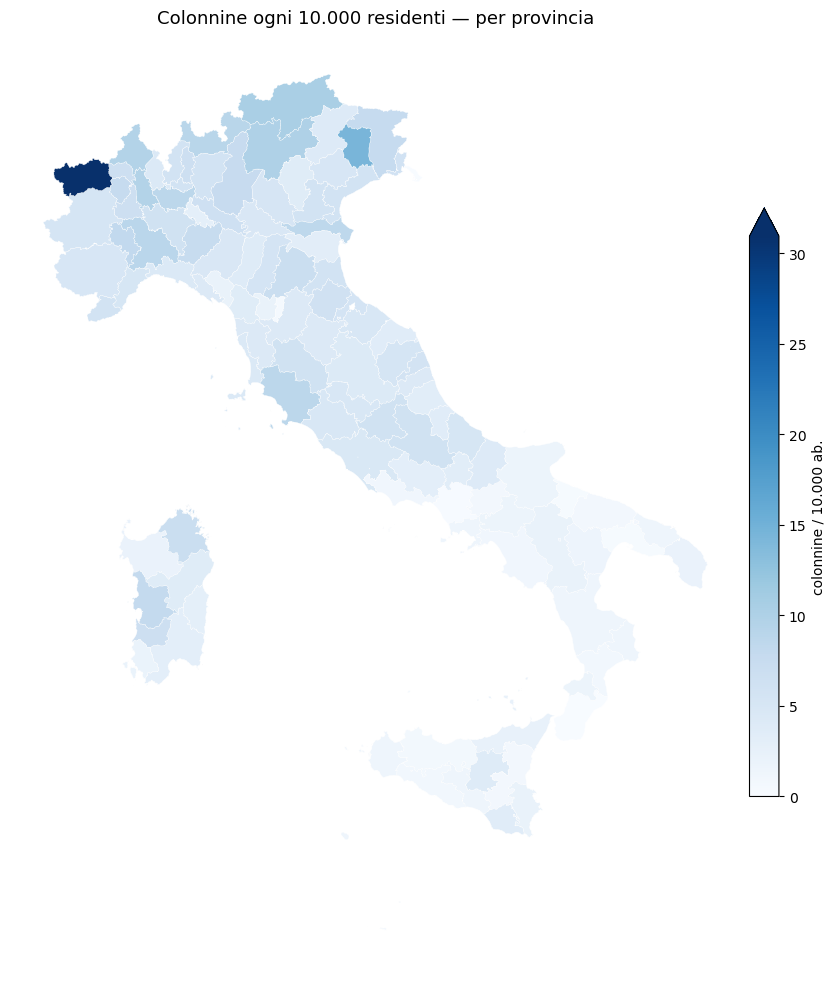

In [6]:
m_choro(P, "colonnine", "Blues", "Numero di colonnine per provincia",
        "atlantev3_1c_colonnine_assolute.png", vmin=0, vmax=P.colonnine.quantile(0.95),
        label="n. colonnine", extend="max")
m_choro(P, "colonnine_per_10000", "Blues", "Colonnine ogni 10.000 residenti — per provincia",
        "atlantev3_1c_colonnine_percapita.png", vmin=0, vmax=P.colonnine_per_10000.quantile(0.95),
        label="colonnine / 10.000 ab.", extend="max")


# Parte 2 — Auto elettriche (domanda corretta)

## 2a. Per sezione — concentrazione a esagoni (magma, viridis, plasma separati)

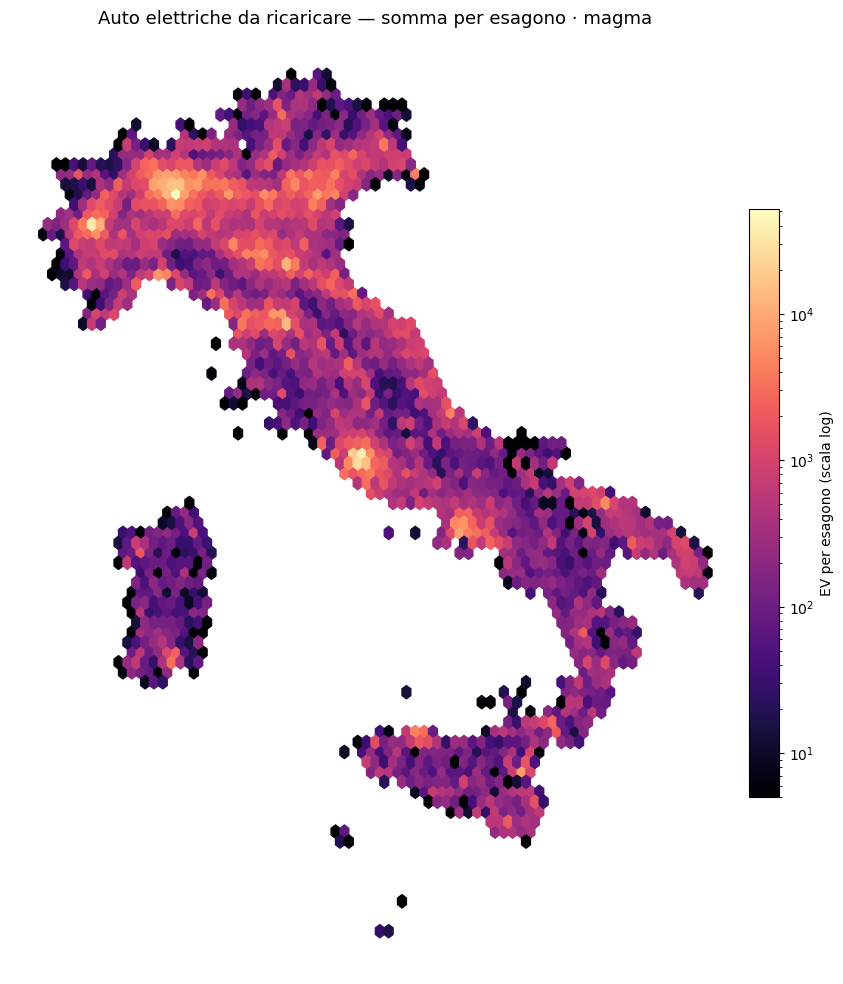

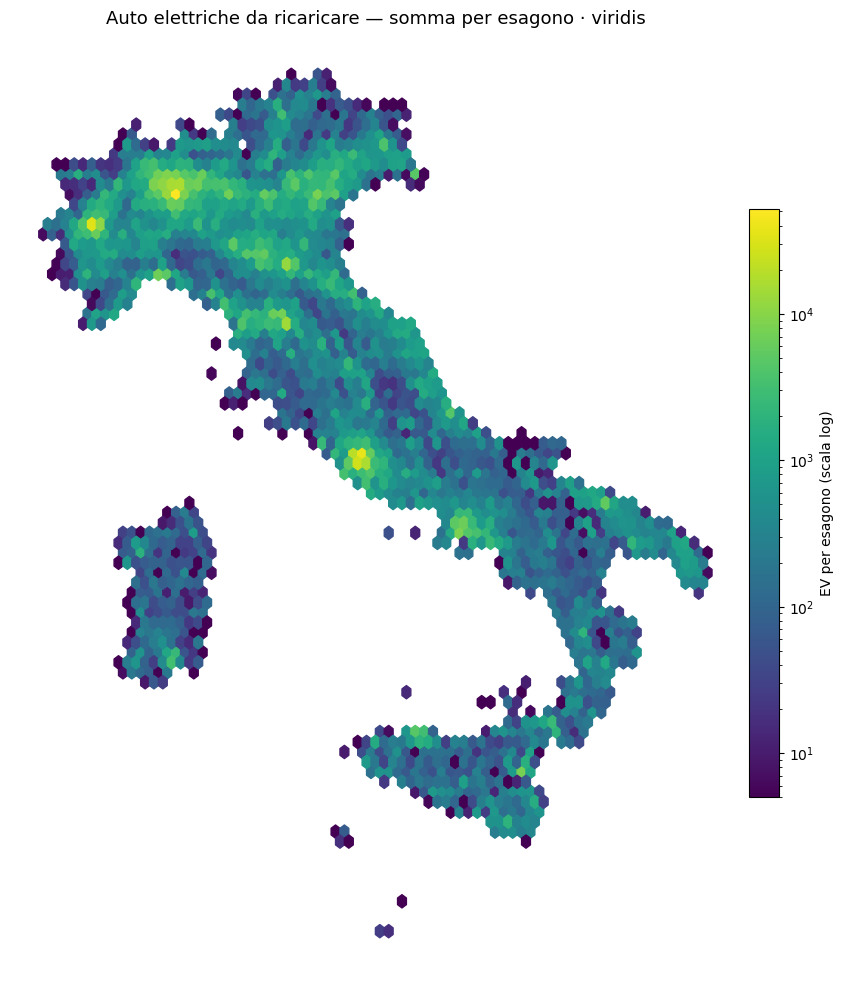

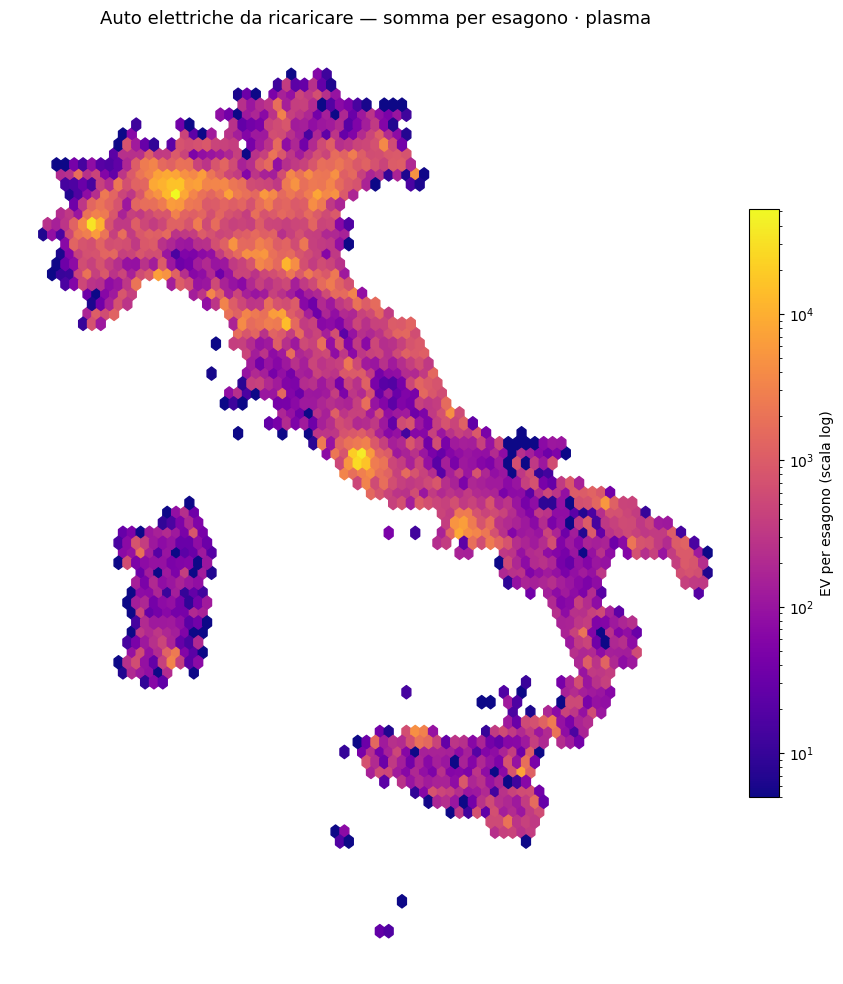

In [7]:
for cm in ["magma","viridis","plasma"]:
    m_hexbin(gdf.px.values, gdf.py.values, C=gdf.domanda_v3.values, cmap=cm,
             titolo=f"Auto elettriche da ricaricare — somma per esagono · {cm}",
             fname=f"atlantev3_2a_ev_sezione_{cm}.png", reduce=np.sum, gridsize=75,
             norm=LogNorm(vmin=5), label="EV per esagono (scala log)")


## 2b. Per provincia — EV ogni 1.000 residenti · nuovi gradienti
La densità è abbastanza uniforme dopo la correzione flotte: per farla "parlare"
usiamo una scala **divergente centrata sulla mediana** (province sopra/sotto la
media saltano all'occhio), più una variante ad alto contrasto.

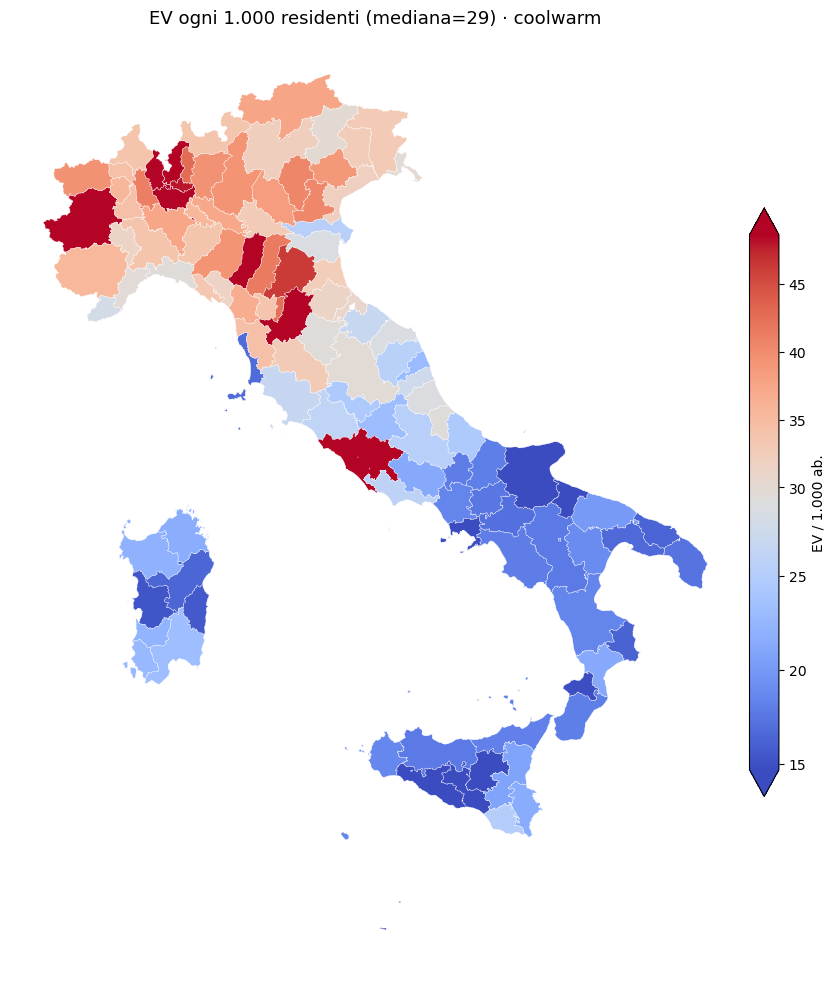

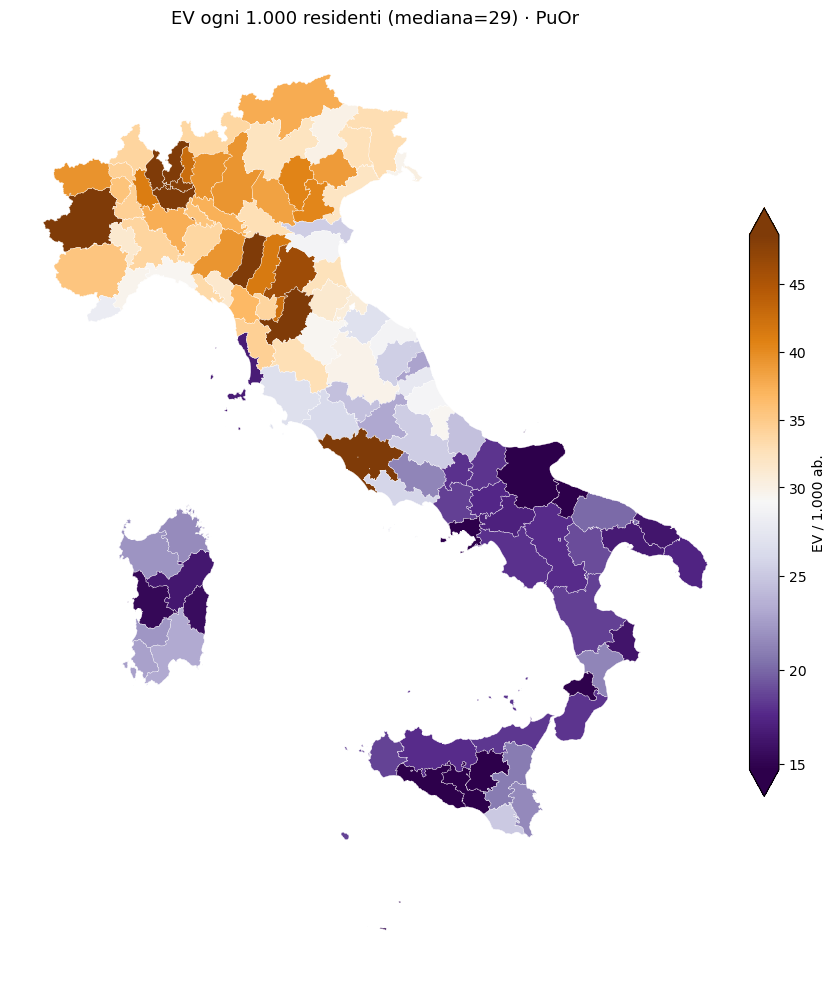

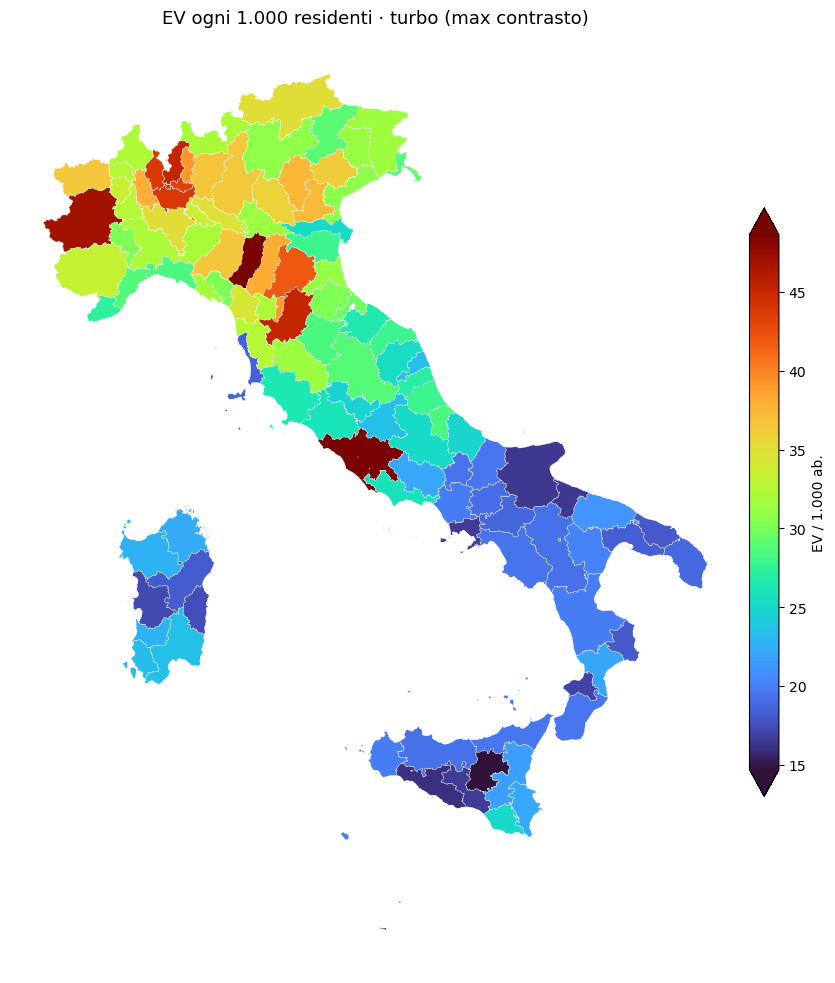

In [8]:
med = P.ev_per_1000.median()
norm_ev = TwoSlopeNorm(vmin=P.ev_per_1000.quantile(0.05), vcenter=med, vmax=P.ev_per_1000.quantile(0.95))
m_choro(P, "ev_per_1000", "coolwarm", f"EV ogni 1.000 residenti (mediana={med:.0f}) · coolwarm",
        "atlantev3_2b_ev_coolwarm.png", norm=norm_ev, label="EV / 1.000 ab.", extend="both")
m_choro(P, "ev_per_1000", "PuOr_r", f"EV ogni 1.000 residenti (mediana={med:.0f}) · PuOr",
        "atlantev3_2b_ev_puor.png", norm=norm_ev, label="EV / 1.000 ab.", extend="both")
m_choro(P, "ev_per_1000", "turbo", "EV ogni 1.000 residenti · turbo (max contrasto)",
        "atlantev3_2b_ev_turbo.png", vmin=P.ev_per_1000.quantile(0.05), vmax=P.ev_per_1000.quantile(0.95),
        label="EV / 1.000 ab.", extend="both")


# Parte 3 — GAP score

## 3a. Per sezione (esagoni) — GAP medio con segno: coolwarm vs RdBu_r

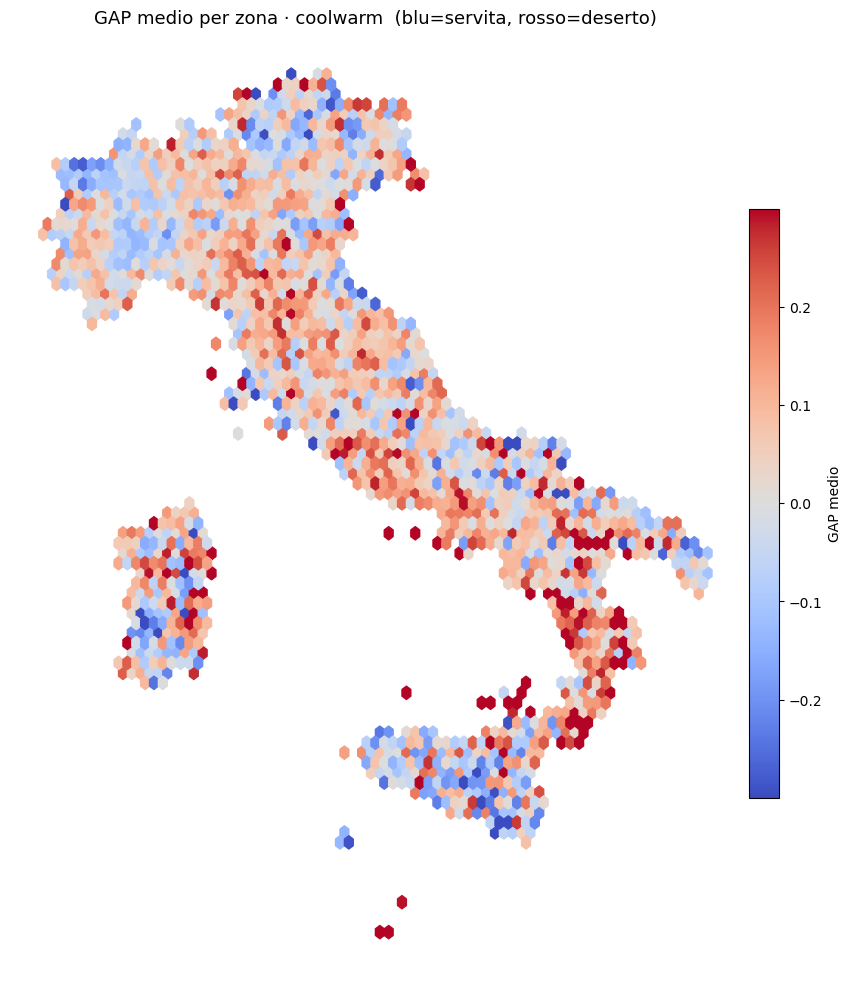

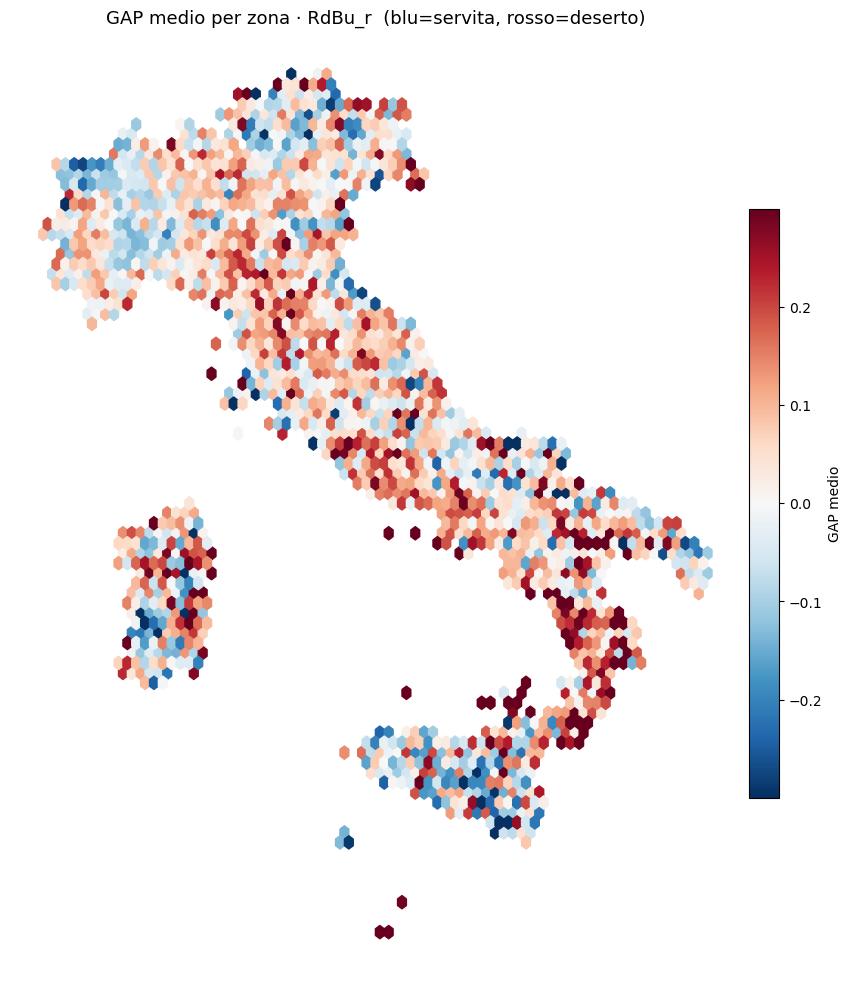

In [9]:
NORM = TwoSlopeNorm(vmin=-0.3, vcenter=0, vmax=0.3)
for cm in ["coolwarm","RdBu_r"]:
    m_hexbin(e.px.values, e.py.values, C=e.gap_score_v3.values, cmap=cm,
             titolo=f"GAP medio per zona · {cm}  (blu=servita, rosso=deserto)",
             fname=f"atlantev3_3a_gapmedio_{cm}.png", reduce=np.mean, gridsize=75,
             norm=NORM, label="GAP medio")


## 3a-bis. Per sezione — quota di sezioni-deserto: rosso-giallo, ricerca del migliore

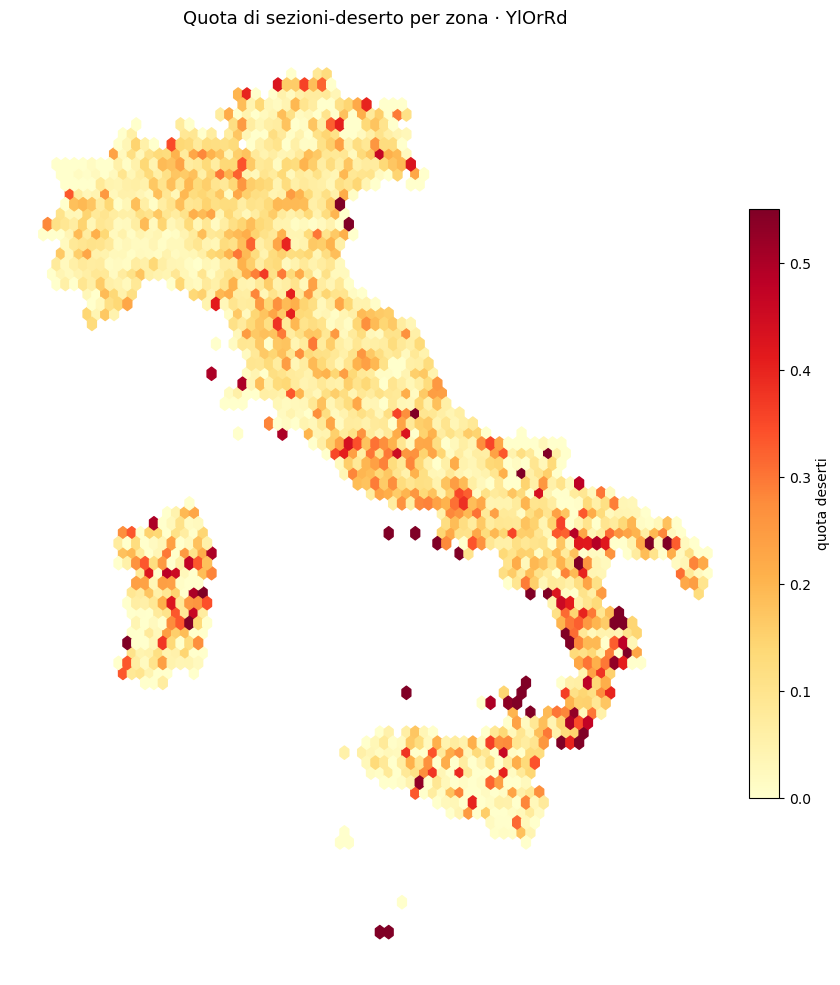

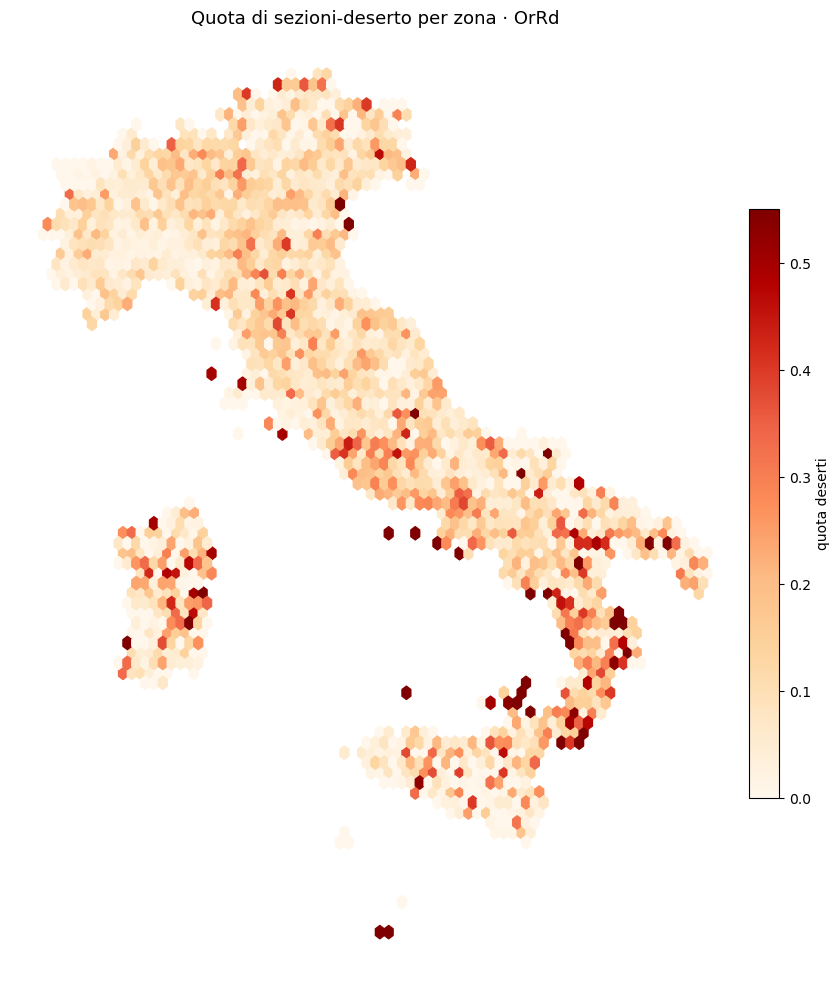

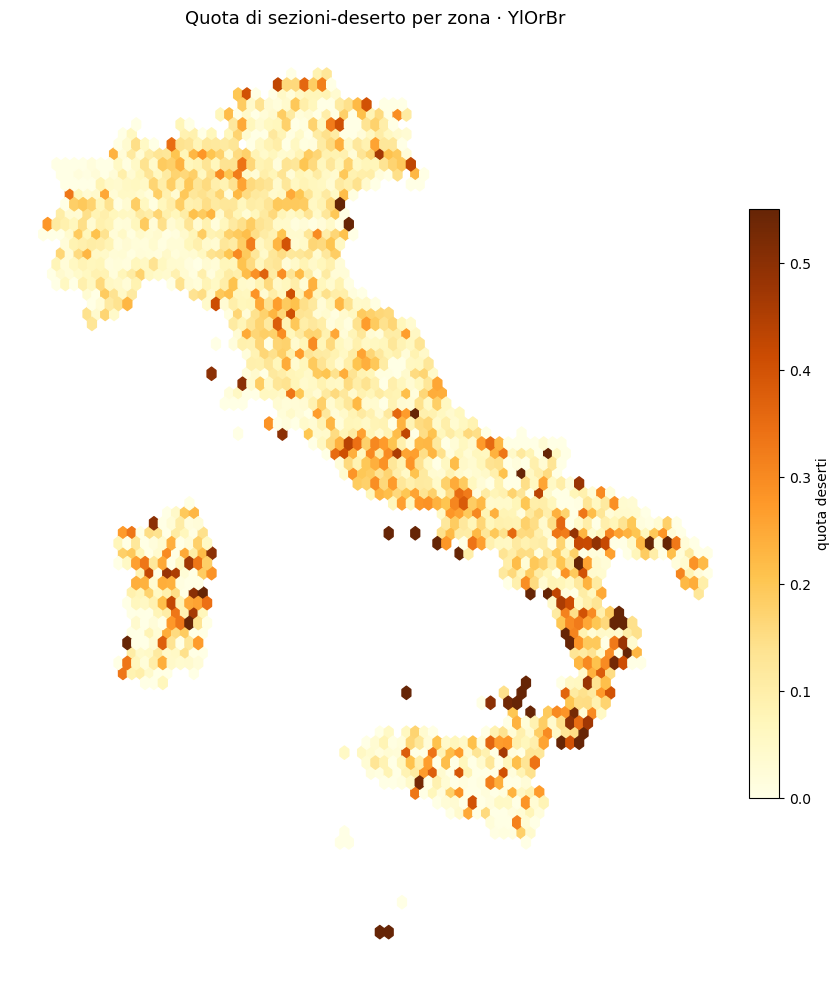

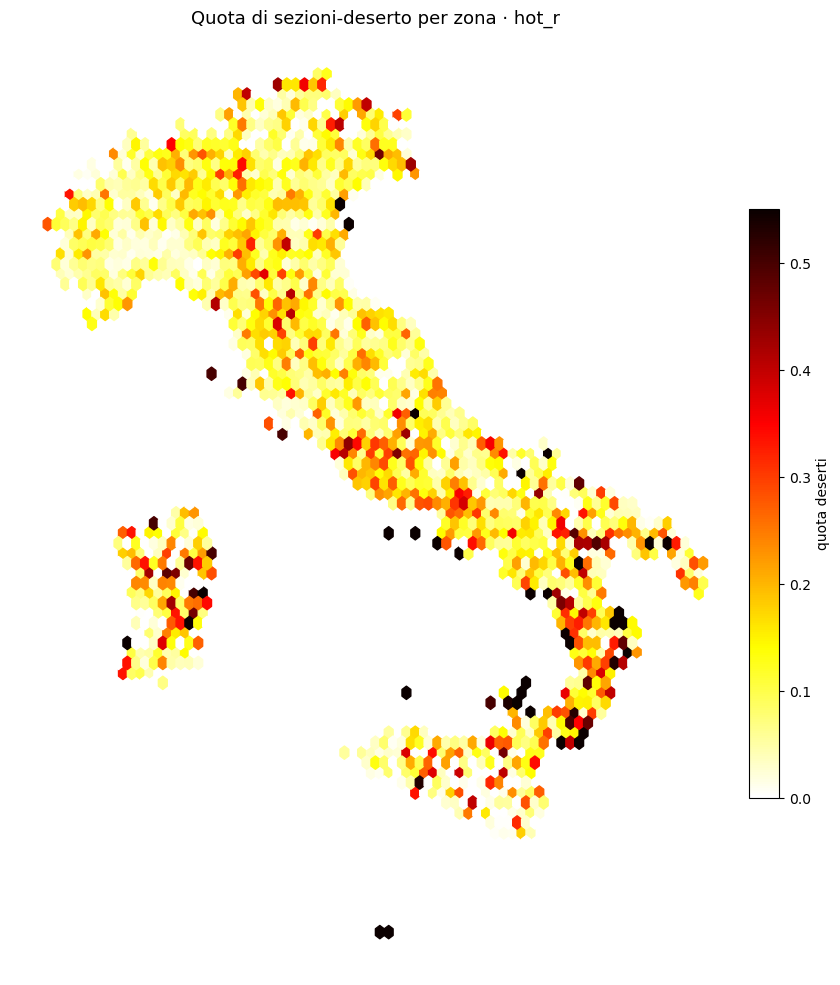

In [10]:
desert = (e.gap_score_v3 > SOGLIA).astype(float).values
for cm in ["YlOrRd","OrRd","YlOrBr","hot_r"]:
    m_hexbin(e.px.values, e.py.values, C=desert, cmap=cm,
             titolo=f"Quota di sezioni-deserto per zona · {cm}",
             fname=f"atlantev3_3a_deserti_{cm}.png", reduce=np.mean, gridsize=75,
             vmin=0, vmax=0.55, label="quota deserti")


## 3b. Per provincia — con legenda
Quota di popolazione in un deserto: un gradiente **solo rosso** (chiaro→scuro) e
uno un po' diverso. Più il GAP medio con segno.

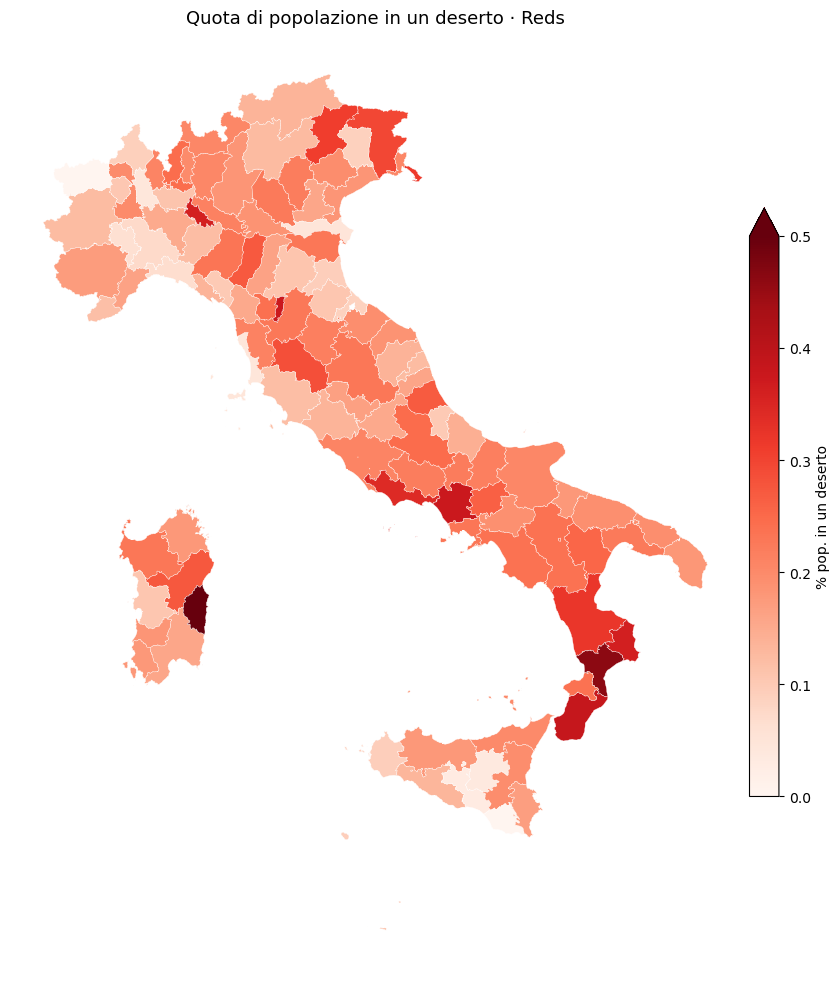

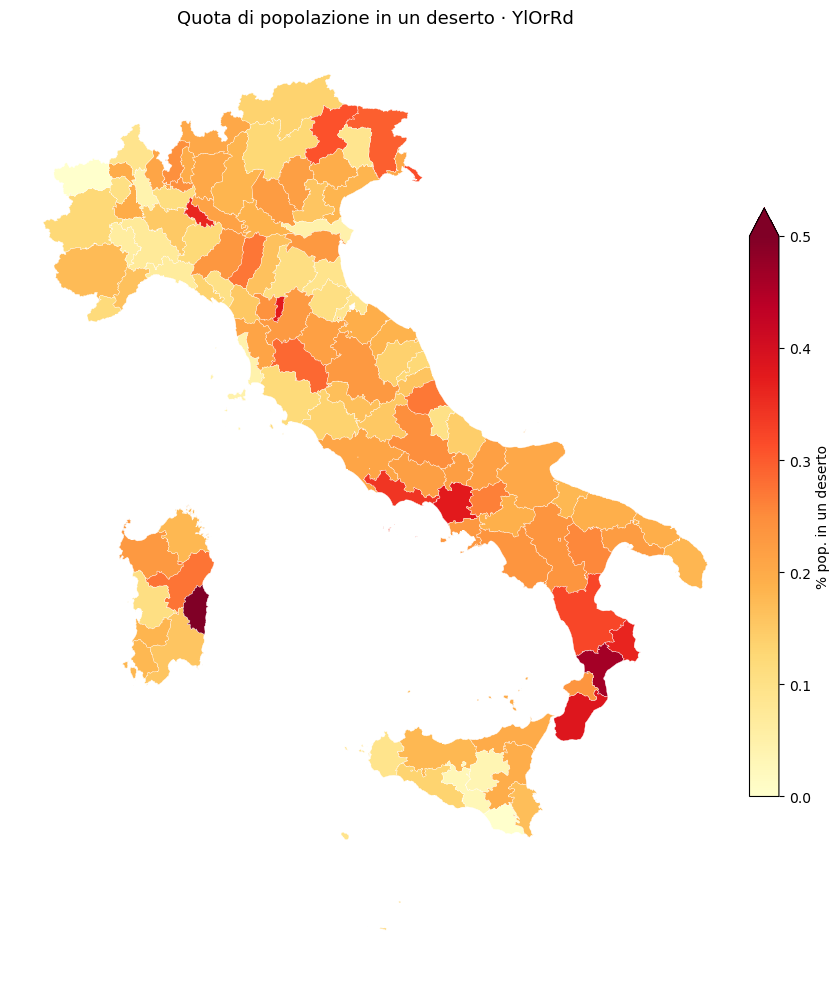

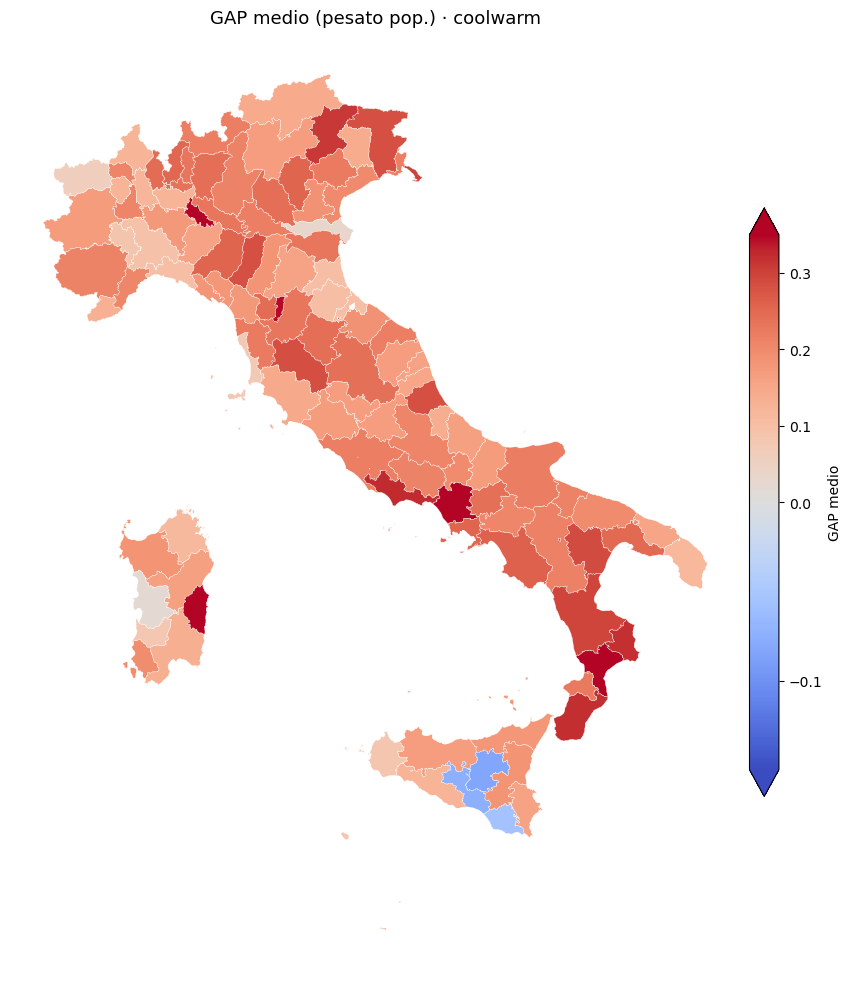

In [11]:
m_choro(P, "quota_deserto", "Reds", "Quota di popolazione in un deserto · Reds",
        "atlantev3_3b_deserto_reds.png", vmin=0, vmax=0.5, label="% pop. in un deserto", extend="max")
m_choro(P, "quota_deserto", "YlOrRd", "Quota di popolazione in un deserto · YlOrRd",
        "atlantev3_3b_deserto_ylorrd.png", vmin=0, vmax=0.5, label="% pop. in un deserto", extend="max")
NORMp = TwoSlopeNorm(vmin=-0.15, vcenter=0, vmax=0.35)
m_choro(P, "gap_medio", "coolwarm", "GAP medio (pesato pop.) · coolwarm",
        "atlantev3_3b_gapmedio_coolwarm.png", norm=NORMp, label="GAP medio", extend="both")


## 3c. Focus provincia di Milano — molte varianti
A livello di sezione la mappa è troppo fitta: proviamo aggregazioni e stili
diversi per capire davvero dove sono i deserti.

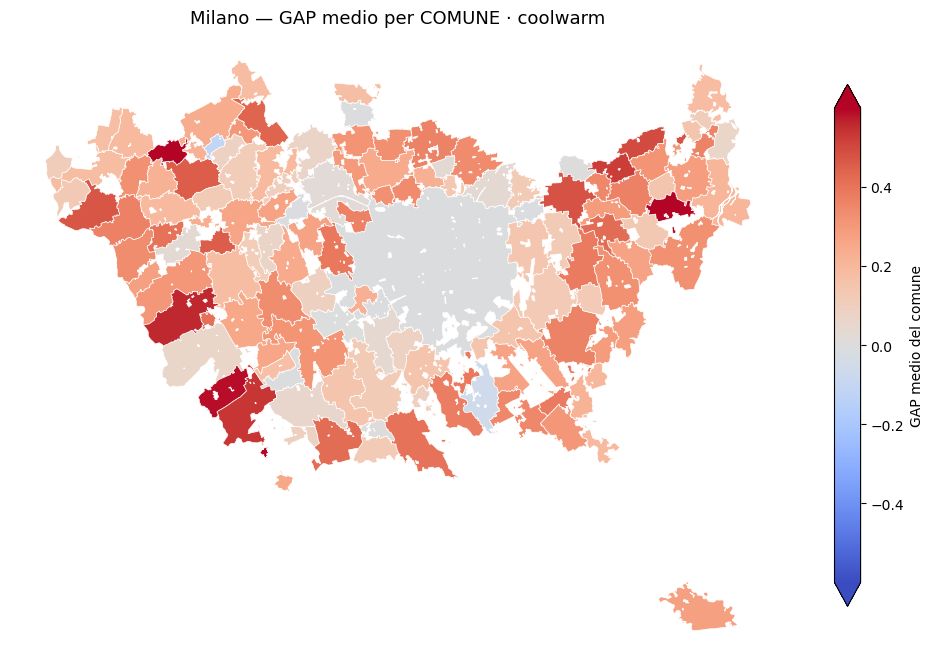

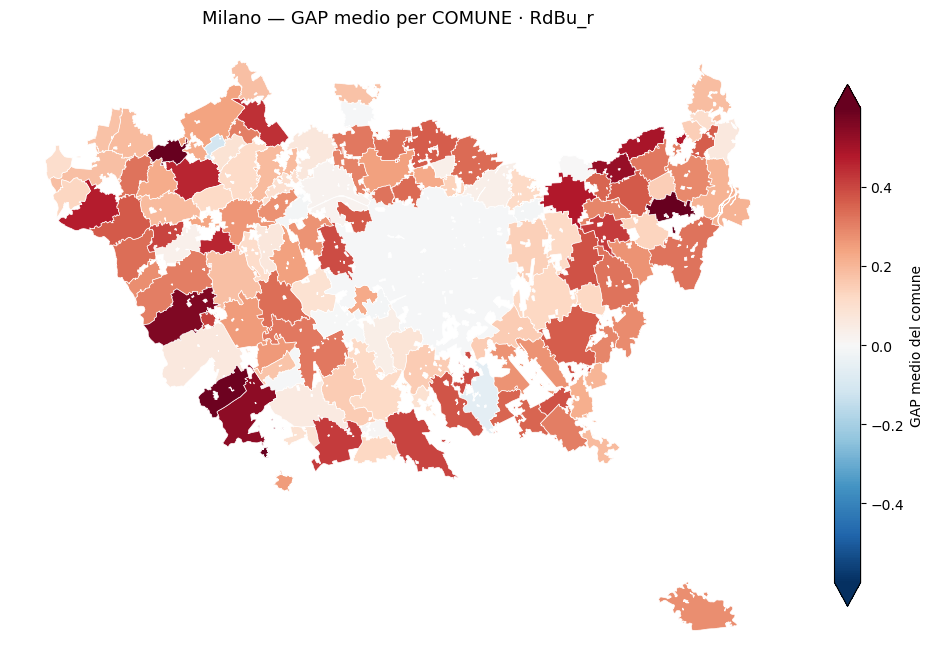

In [12]:
mil = gdf[gdf.PROVINCIA == "Milano"].copy()
mil_e = mil[mil.gap_score_v3.notna()]
GN = TwoSlopeNorm(vmin=-0.6, vcenter=0, vmax=0.6)

# (1) COMUNE: GAP medio pesato per comune (aggregazione più leggibile)
gcom = mil_e.groupby("PROCOM").apply(lambda d: np.average(d.gap_score_v3, weights=d.popg))
milcom = mil.dissolve(by="PROCOM"); milcom["gap"] = gcom
for cm in ["coolwarm","RdBu_r"]:
    fig, ax = plt.subplots(figsize=(10, 9))
    milcom.plot(column="gap", cmap=cm, norm=GN, ax=ax, edgecolor="white", linewidth=0.5,
                legend=True, legend_kwds={"shrink":0.6,"label":"GAP medio del comune","extend":"both"},
                missing_kwds={"color":"#dddddd"})
    ax.set_axis_off(); ax.set_title(f"Milano — GAP medio per COMUNE · {cm}", fontsize=13)
    plt.tight_layout(); plt.savefig(f"atlantev3_3c_milano_comune_{cm}.png", dpi=160, bbox_inches="tight"); plt.show()


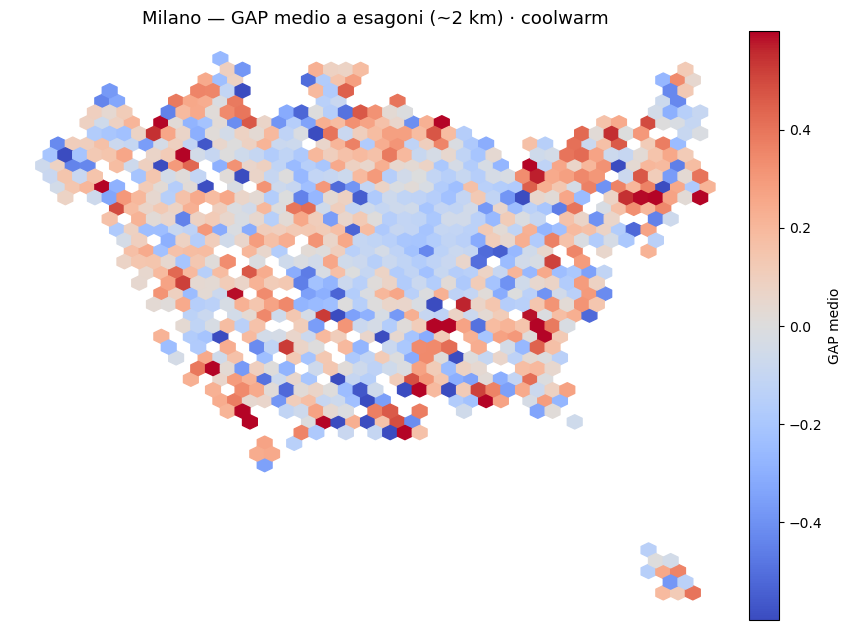

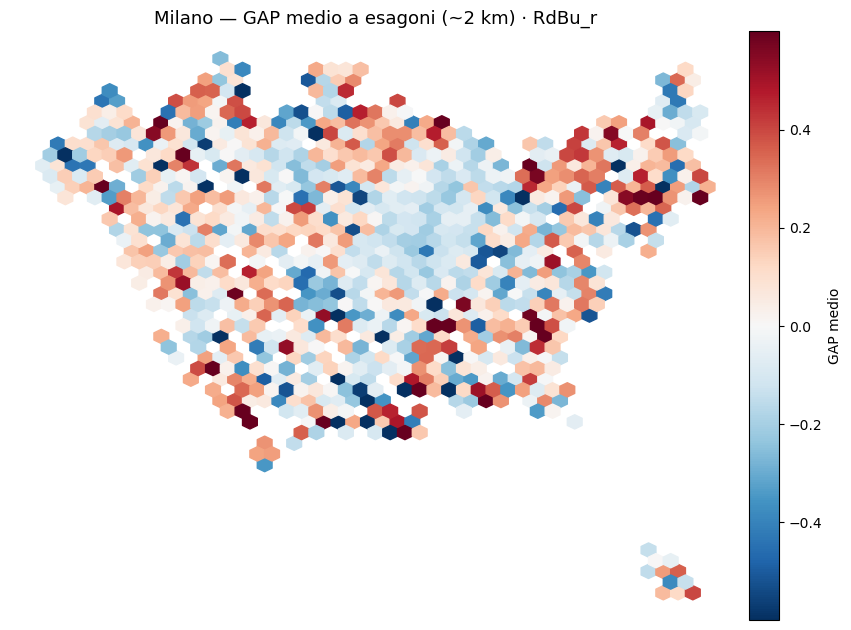

In [13]:
# (2) ESAGONI fini (~2 km) sul GAP di Milano
for cm in ["coolwarm","RdBu_r"]:
    m_hexbin(mil_e.px.values, mil_e.py.values, C=mil_e.gap_score_v3.values, cmap=cm,
             titolo=f"Milano — GAP medio a esagoni (~2 km) · {cm}",
             fname=f"atlantev3_3c_milano_hexbin_{cm}.png", reduce=np.mean, gridsize=45,
             norm=GN, label="GAP medio")


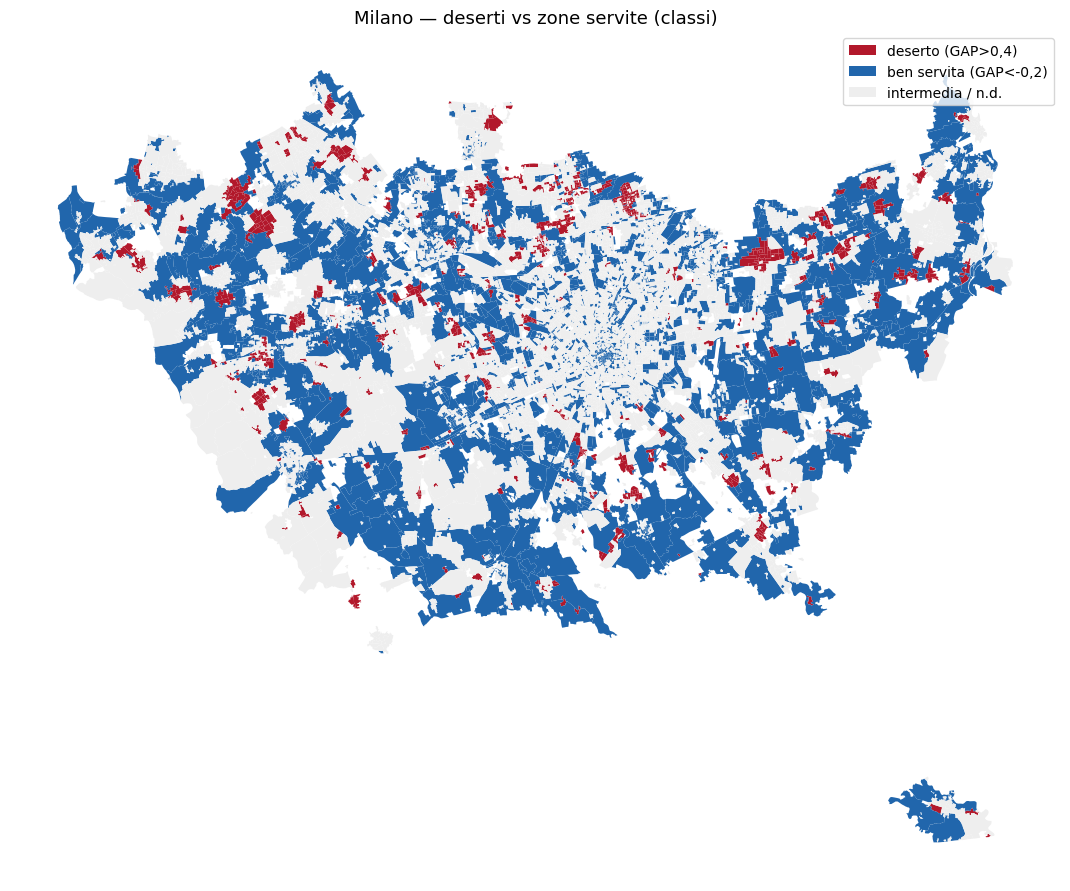

In [14]:
# (3) BINARIO: solo deserti (rosso) vs ben servite (blu) vs intermedie (grigio)
mil["cat"] = np.select([mil.gap_score_v3 > SOGLIA, mil.gap_score_v3 < -0.2],
                       ["deserto (GAP>0,4)", "ben servita (GAP<-0,2)"], default="intermedia / n.d.")
colori = {"deserto (GAP>0,4)":"#b2182b", "ben servita (GAP<-0,2)":"#2166ac", "intermedia / n.d.":"#eeeeee"}
fig, ax = plt.subplots(figsize=(11, 9))
for cat, c in colori.items():
    sub = mil[mil.cat == cat]
    if len(sub): sub.plot(ax=ax, color=c, linewidth=0)
ax.set_axis_off(); ax.set_title("Milano — deserti vs zone servite (classi)", fontsize=13)
ax.legend(handles=[Patch(facecolor=c, label=k) for k, c in colori.items()], loc="upper right", frameon=True)
plt.tight_layout(); plt.savefig("atlantev3_3c_milano_binario.png", dpi=160, bbox_inches="tight"); plt.show()


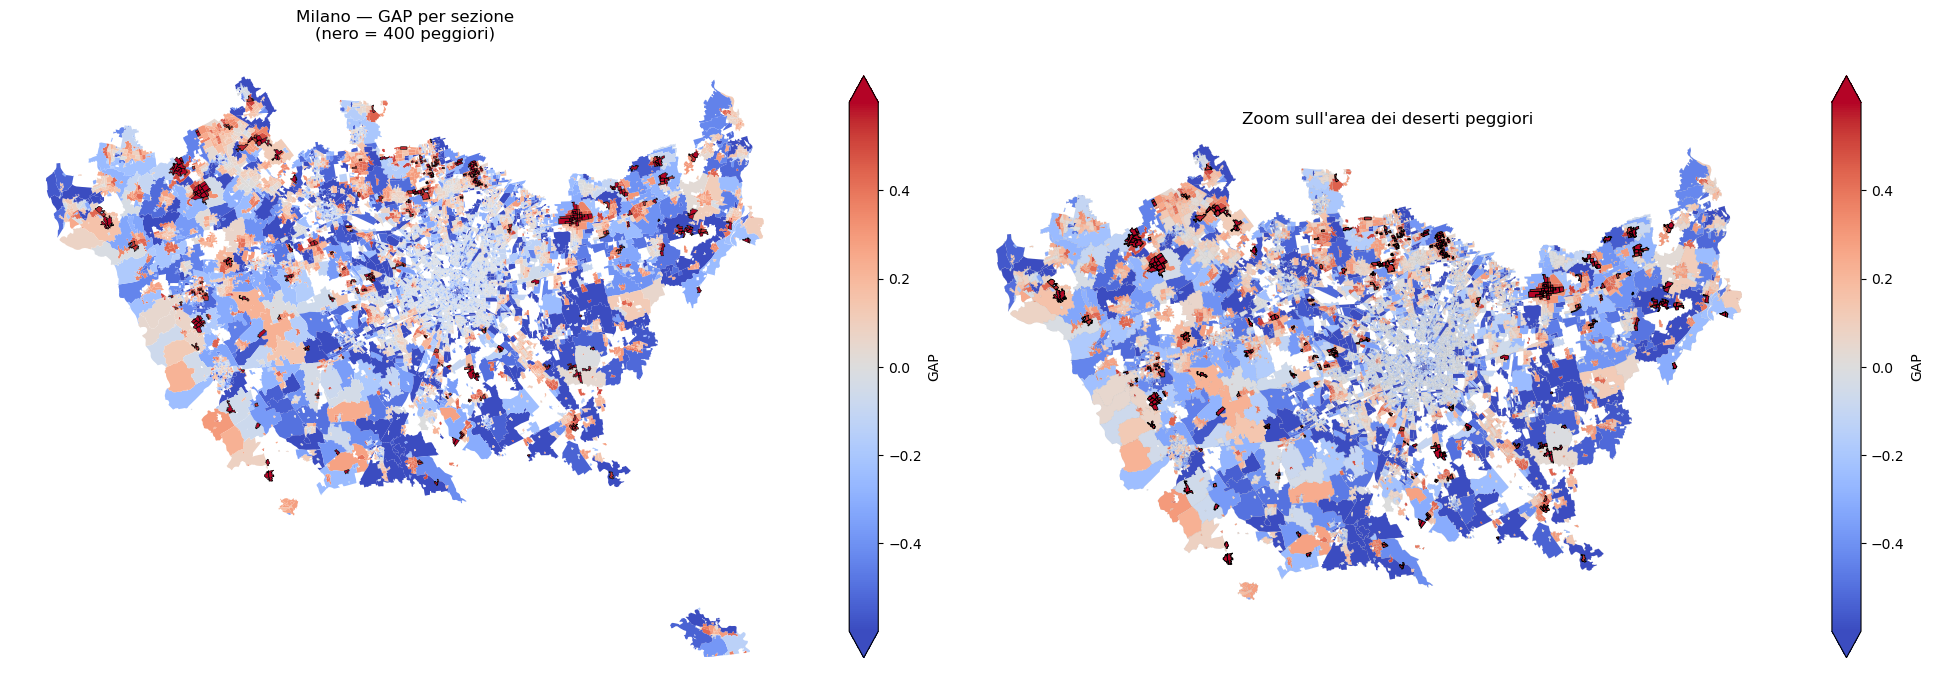

Comuni con più sezioni tra i 400 peggiori deserti di Milano:
        sezioni                 COMUNE
PROCOM                                
15077        53      Cinisello Balsamo
15146        41                 Milano
15166        41        Paderno Dugnano
15070        27  Cernusco sul Naviglio
15130        15                Magenta
15184        14   Robecco sul Naviglio
15041        13          Busto Garolfo
15178        12     Pozzuolo Martesana
15139         9               Mediglia
15099         9                Dairago


In [15]:
# (4) SEZIONE + evidenza dei 400 peggiori + zoom sull'area
peg = mil_e.nlargest(400, "gap_score_v3")
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
mil.plot(column="gap_score_v3", cmap="coolwarm", norm=GN, ax=axes[0], linewidth=0,
         legend=True, legend_kwds={"shrink":0.6,"label":"GAP","extend":"both"})
peg.boundary.plot(ax=axes[0], color="black", linewidth=0.4)
axes[0].set_axis_off(); axes[0].set_title("Milano — GAP per sezione\n(nero = 400 peggiori)", fontsize=12)
minx,miny,maxx,maxy = peg.total_bounds; mx,my=(maxx-minx)*.08,(maxy-miny)*.08
box = mil.cx[minx-mx:maxx+mx, miny-my:maxy+my]
box.plot(column="gap_score_v3", cmap="coolwarm", norm=GN, ax=axes[1], linewidth=0.05, edgecolor="#999999",
         legend=True, legend_kwds={"shrink":0.6,"label":"GAP","extend":"both"})
peg.boundary.plot(ax=axes[1], color="black", linewidth=0.6)
axes[1].set_xlim(minx-mx,maxx+mx); axes[1].set_ylim(miny-my,maxy+my)
axes[1].set_axis_off(); axes[1].set_title("Zoom sull'area dei deserti peggiori", fontsize=12)
plt.tight_layout(); plt.savefig("atlantev3_3c_milano_sezione_zoom.png", dpi=160, bbox_inches="tight"); plt.show()

nome_c = pd.read_parquet(PARQUET, columns=["SEZ2011","COMUNE"])
nome_c["PROCOM"] = (nome_c.SEZ2011 // 10_000_000).astype("int64")
nome_c = nome_c.dropna(subset=["COMUNE"]).groupby("PROCOM")["COMUNE"].first()
print("Comuni con più sezioni tra i 400 peggiori deserti di Milano:")
print(peg.groupby("PROCOM").size().to_frame("sezioni").join(nome_c).sort_values("sezioni", ascending=False).head(10).to_string())


## Riepilogo gradienti consigliati
- **densità colonnine / EV**: `viridis` o `magma` (sfondo scuro, picchi in
  risalto); `plasma` ottima alternativa.
- **colonnine per provincia**: `Blues` (chiaro→scuro).
- **EV per provincia**: divergente centrata sulla mediana (`coolwarm`/`PuOr`) per
  vedere sopra/sotto la media.
- **GAP con segno**: `coolwarm` (o `RdBu_r`).
- **quota-deserti**: `YlOrRd` / `Reds`.
- **Milano**: la vista a **comune** e quella **binaria** (deserto/servita) sono
  le più leggibili; l'esagonale ~2 km è un buon compromesso.